2.1

1. 非线性激活函数的重要性
已知：
隐藏层 h = W1 * x + b1 （无激活函数，线性激活）
输出层 o = W2 * h + b2

推导过程：
将隐藏层表达式代入输出层：
o = W2 * (W1 * x + b1) + b2
o = W2 * W1 * x + W2 * b1 + b2

令：
W' = W2 * W1
b' = W2 * b1 + b2

则网络等价于单层神经网络：
o = W' * x + b'

结论：没有非线性激活函数的多层感知机可以压缩为单层线性网络，无法逼近非线性函数。因此非线性激活函数对于多层感知机的表达能力至关重要。

2. 激活函数性质分析
(1) Sigmoid函数

数学表达式：
sigma(x) = 1 / (1 + e^(-x))

导数推导：
sigma'(x) = d/dx [1 / (1 + e^(-x))] = e^(-x) / (1 + e^(-x))^2
= [1 / (1 + e^(-x))] * [e^(-x) / (1 + e^(-x))]
= sigma(x) * (1 - sigma(x))

因此：
sigma'(x) = sigma(x) * (1 - sigma(x))

(2) tanh函数

数学表达式：
tanh(x) = (e^x - e^(-x)) / (e^x + e^(-x))

导数推导：
tanh'(x) = [(e^x + e^(-x))^2 - (e^x - e^(-x))^2] / (e^x + e^(-x))^2
= 1 - [(e^x - e^(-x)) / (e^x + e^(-x))]^2
= 1 - tanh^2(x)

因此：
tanh'(x) = 1 - tanh^2(x)



2.2

In [4]:
import torch
import numpy as np
import gzip
import os
import urllib.request
from torch.utils.data import DataLoader, TensorDataset

print("正在下载并加载 Fashion-MNIST 数据...")

def load_fashion_mnist():
    base_url = "http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/"
    files = {
        'train_images': 'train-images-idx3-ubyte.gz',
        'train_labels': 'train-labels-idx1-ubyte.gz',
        'test_images': 't10k-images-idx3-ubyte.gz',
        'test_labels': 't10k-labels-idx1-ubyte.gz'
    }
    
    data_dir = './fashion_mnist_data'
    os.makedirs(data_dir, exist_ok=True)
    
    def download_file(filename):
        filepath = os.path.join(data_dir, filename)
        if not os.path.exists(filepath):
            print(f"正在下载 {filename}...")
            urllib.request.urlretrieve(base_url + filename, filepath)
        return filepath
    
    def load_images(filename):
        filepath = download_file(filename)
        with gzip.open(filepath, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        return data.reshape(-1, 784).astype(np.float32) / 255.0
    
    def load_labels(filename):
        filepath = download_file(filename)
        with gzip.open(filepath, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=8)
        return data
    
    X_train = load_images(files['train_images'])
    y_train = load_labels(files['train_labels'])
    X_test = load_images(files['test_images'])
    y_test = load_labels(files['test_labels'])
    
    return X_train, y_train, X_test, y_test

# 加载数据
X_train_np, y_train_np, X_test_np, y_test_np = load_fashion_mnist()

print(f"训练集大小: {X_train_np.shape}")
print(f"训练标签大小: {y_train_np.shape}")
print(f"测试集大小: {X_test_np.shape}")
print(f"测试标签大小: {y_test_np.shape}")

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

batch_size = 128
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_size = 784
hidden_size = 256
output_size = 10
lr = 0.1
epochs = 20

W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

W1.requires_grad_(True)
b1.requires_grad_(True)
W2.requires_grad_(True)
b2.requires_grad_(True)

def relu(x):
    return torch.maximum(torch.tensor(0.0), x)

def cross_entropy_with_softmax(logits, y):
    shifted_logits = logits - logits.max(dim=1, keepdim=True)[0]
    exp_logits = torch.exp(shifted_logits)
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8)
    return loss.mean()

# 前向传播
def forward(x):
    h = x @ W1 + b1
    h_relu = relu(h)
    o = h_relu @ W2 + b2
    return o

# SGD更新
def sgd_step(params, lr):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad
            param.grad.zero_()

# 训练循环
train_losses = []
test_accs = []

print("\n开始训练...")
for epoch in range(epochs):
    epoch_loss = 0
    for X, y in train_loader:
        logits = forward(X)
        loss = cross_entropy_with_softmax(logits, y)
        
        loss.backward()
        sgd_step([W1, b1, W2, b2], lr)
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 测试准确率
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:
            logits = forward(X)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    test_accs.append(acc)
    
    print(f"Epoch {epoch+1:2d}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

print("\n训练完成！")

正在下载并加载 Fashion-MNIST 数据...
正在下载 train-images-idx3-ubyte.gz...
正在下载 train-labels-idx1-ubyte.gz...
正在下载 t10k-images-idx3-ubyte.gz...
正在下载 t10k-labels-idx1-ubyte.gz...
训练集大小: (60000, 784)
训练标签大小: (60000,)
测试集大小: (10000, 784)
测试标签大小: (10000,)

开始训练...
Epoch  1, Loss: 0.8385, Test Acc: 0.7968
Epoch  2, Loss: 0.5101, Test Acc: 0.8145
Epoch  3, Loss: 0.4516, Test Acc: 0.8384
Epoch  4, Loss: 0.4182, Test Acc: 0.8206
Epoch  5, Loss: 0.3955, Test Acc: 0.8338
Epoch  6, Loss: 0.3794, Test Acc: 0.8424
Epoch  7, Loss: 0.3635, Test Acc: 0.8552
Epoch  8, Loss: 0.3500, Test Acc: 0.8524
Epoch  9, Loss: 0.3402, Test Acc: 0.8619
Epoch 10, Loss: 0.3296, Test Acc: 0.8673
Epoch 11, Loss: 0.3233, Test Acc: 0.8700
Epoch 12, Loss: 0.3140, Test Acc: 0.8626
Epoch 13, Loss: 0.3065, Test Acc: 0.8636
Epoch 14, Loss: 0.3011, Test Acc: 0.8706
Epoch 15, Loss: 0.2964, Test Acc: 0.8720
Epoch 16, Loss: 0.2891, Test Acc: 0.8774
Epoch 17, Loss: 0.2840, Test Acc: 0.8774
Epoch 18, Loss: 0.2780, Test Acc: 0.8788
Epoch 19, Los

3.1

1. 过拟合与欠拟合
训练误差与泛化误差的区别：

训练误差：模型在训练集上的误差，反映模型对训练数据的拟合程度

泛化误差：模型在未见过的测试集上的期望误差，反映模型的真实预测能力

当训练误差极低但泛化误差很高时，模型处于过拟合状态。

缓解过拟合的方法：

减少模型复杂度（减少层数或神经元数量）

使用正则化（L1/L2正则化、Dropout）

增加训练数据量或使用数据增强

早停（Early Stopping）

2. K折交叉验证
算法步骤：

1.将数据集随机打乱，划分为K个大小相近的子集（折）

2.对于 k = 1 到 K：

将第k个子集作为验证集

其余K-1个子集合并作为训练集

在训练集上训练模型，在验证集上评估性能

记录该次验证的评估指标

3.计算K次验证结果的平均值作为最终性能指标

4.可选：使用全部K个折的数据重新训练最终模型

3.2

=== 实验1: 无正则化 ===
Epoch 10, Train Loss: 0.4075, Val Loss: 0.3972
Epoch 20, Train Loss: 0.4095, Val Loss: 0.3949
Epoch 30, Train Loss: 0.4159, Val Loss: 0.3919
Epoch 40, Train Loss: 0.3227, Val Loss: 0.3857
Epoch 50, Train Loss: 0.3415, Val Loss: 0.3745
Epoch 60, Train Loss: 0.2224, Val Loss: 0.3533
Epoch 70, Train Loss: 0.1694, Val Loss: 0.3297
Epoch 80, Train Loss: 0.1132, Val Loss: 0.3094

=== 实验2: 权重衰减 (L2) ===
Epoch 10, Train Loss: 0.3827, Val Loss: 0.3972
Epoch 20, Train Loss: 0.4433, Val Loss: 0.3960
Epoch 30, Train Loss: 0.4628, Val Loss: 0.3937
Epoch 40, Train Loss: 0.3786, Val Loss: 0.3874
Epoch 50, Train Loss: 0.2976, Val Loss: 0.3780
Epoch 60, Train Loss: 0.2402, Val Loss: 0.3621
Epoch 70, Train Loss: 0.1871, Val Loss: 0.3427
Epoch 80, Train Loss: 0.0939, Val Loss: 0.3236

=== 实验3: Dropout ===
Epoch 10, Train Loss: 0.4391, Val Loss: 0.3959
Epoch 20, Train Loss: 0.3806, Val Loss: 0.3939
Epoch 30, Train Loss: 0.4055, Val Loss: 0.3894
Epoch 40, Train Loss: 0.3818, Val Loss: 0.3

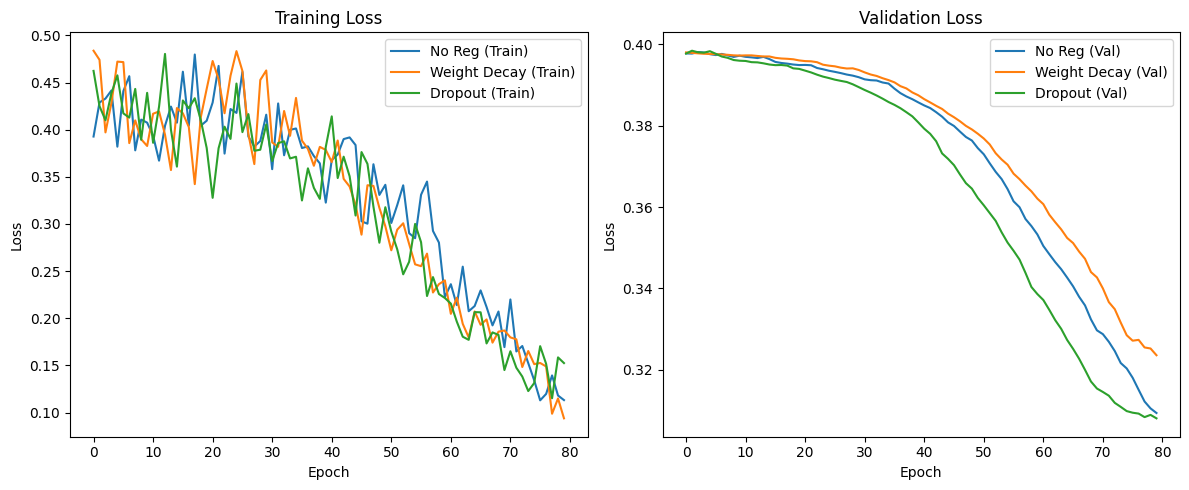


最终验证损失对比:
无正则化: 0.3094
权重衰减: 0.3236
Dropout: 0.3081


In [6]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
torch.manual_seed(42)

n_samples = 100
n_features = 100
X_train = np.random.randn(n_samples, n_features)
y_train = np.sin(X_train[:, 0]) + 0.1 * np.random.randn(n_samples)

X_val = np.random.randn(50, n_features)
y_val = np.sin(X_val[:, 0]) + 0.1 * np.random.randn(50)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0, weight_decay=0.0):
        self.W1 = torch.randn(input_dim, hidden_dim) * 0.01
        self.b1 = torch.zeros(hidden_dim)
        self.W2 = torch.randn(hidden_dim, output_dim) * 0.01
        self.b2 = torch.zeros(output_dim)
        self.W1.requires_grad_(True)
        self.b1.requires_grad_(True)
        self.W2.requires_grad_(True)
        self.b2.requires_grad_(True)
        self.dropout_rate = dropout_rate
        self.weight_decay = weight_decay
    
    def train(self):  
        self.training = True
    
    def eval(self):   
        self.training = False
    
    def dropout_layer(self, x, is_training):
        if not is_training or self.dropout_rate == 0:
            return x
        mask = (torch.rand(x.shape) > self.dropout_rate).float()
        return x * mask / (1.0 - self.dropout_rate)
    
    def forward(self, x, is_training=True):
        h = x @ self.W1 + self.b1
        h = torch.relu(h)
        h = self.dropout_layer(h, is_training)
        out = h @ self.W2 + self.b2
        return out
    
    def parameters(self):
        return [self.W1, self.b1, self.W2, self.b2]
    
    def zero_grad(self):
        for p in self.parameters():
            if p.grad is not None:
                p.grad.zero_()
    
    def sgd_step(self, lr):
        with torch.no_grad():
            for p in self.parameters():
                # 应用权重衰减
                grad = p.grad + self.weight_decay * p if self.weight_decay > 0 else p.grad
                p -= lr * grad
                p.grad.zero_()

def mse_loss(pred, target):
    return ((pred - target) ** 2).mean()

def train_model(model, train_loader, val_loader, epochs=50, lr=0.01):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()  
        epoch_loss = 0
        for X, y in train_loader:
            pred = model.forward(X, is_training=model.training)  
            loss = mse_loss(pred, y)
            loss.backward()
            model.sgd_step(lr)
            epoch_loss += loss.item()
        
        train_losses.append(epoch_loss / len(train_loader))
        
        model.eval()  
        val_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                pred = model.forward(X, is_training=model.training)  
                val_loss += mse_loss(pred, y).item()
        val_losses.append(val_loss / len(val_loader))
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    return train_losses, val_losses

# 对比实验
input_dim, hidden_dim, output_dim = n_features, 64, 1
epochs, lr = 80, 0.01

print("=== 实验1: 无正则化 ===")
model_no_reg = MLP(input_dim, hidden_dim, output_dim, dropout_rate=0.0, weight_decay=0.0)
train_losses1, val_losses1 = train_model(model_no_reg, train_loader, val_loader, epochs, lr)

print("\n=== 实验2: 权重衰减 (L2) ===")
model_wd = MLP(input_dim, hidden_dim, output_dim, dropout_rate=0.0, weight_decay=0.001)
train_losses2, val_losses2 = train_model(model_wd, train_loader, val_loader, epochs, lr)

print("\n=== 实验3: Dropout ===")
model_dropout = MLP(input_dim, hidden_dim, output_dim, dropout_rate=0.5, weight_decay=0.0)
train_losses3, val_losses3 = train_model(model_dropout, train_loader, val_loader, epochs, lr)

# 绘制对比曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses1, label='No Reg (Train)')
plt.plot(train_losses2, label='Weight Decay (Train)')
plt.plot(train_losses3, label='Dropout (Train)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_losses1, label='No Reg (Val)')
plt.plot(val_losses2, label='Weight Decay (Val)')
plt.plot(val_losses3, label='Dropout (Val)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

print("\n最终验证损失对比:")
print(f"无正则化: {val_losses1[-1]:.4f}")
print(f"权重衰减: {val_losses2[-1]:.4f}")
print(f"Dropout: {val_losses3[-1]:.4f}")

4.1

1. 梯度消失与梯度爆炸
考虑一个d层的深层神经网络，梯度计算中包含多层矩阵连乘项：
连乘项 = ∏_{i=t}^{d-1} (∂h^{i+1} / ∂h^i)

(1) 梯度消失的条件

从矩阵乘法角度：每层权重矩阵Wi的谱范数（最大奇异值）小于1，多层矩阵连乘后，梯度范数以指数速度衰减到0。

从激活函数导数角度：激活函数导数绝对值小于1。例如Sigmoid的最大导数为0.25，Tanh的最大导数为1。当输入落在饱和区时，导数接近于0。多层连乘后，梯度指数级衰减。

(2) 梯度爆炸的条件

从矩阵乘法角度：每层权重矩阵Wi的谱范数大于1，多层矩阵连乘后，梯度范数以指数速度增长，导致数值溢出。

从激活函数导数角度：权重初始化值过大是主要原因。

(3) 数学量化
∂L/∂h^t = ∂L/∂h^d * ∏{i=t}^{d-1} ( diag(sigma'(h^i)) * W{i+1}^T )

若 ||W_i|| * ||sigma'(h^i)|| < 1，则梯度消失；若大于1，则梯度爆炸。

2. ReLU缓解梯度消失问题的原因

(1) ReLU函数定义
ReLU(x) = max(0, x)

(2) ReLU导数
ReLU'(x) = 1 当 x > 0
ReLU'(x) = 0 当 x ≤ 0

(3) 缓解梯度消失的原因

正区间导数为1：当神经元被激活（x>0）时，导数为1，不会像Sigmoid/Tanh那样压缩梯度，梯度可以无损传播。

无饱和区：ReLU在正半轴没有饱和区域，避免了Sigmoid/Tanh在输入绝对值较大时导数趋近于0的问题。

稀疏激活：一半的神经元输出为0，简化了计算路径，有助于梯度流动。

计算简单：不需要指数运算，数值稳定性更好。

(4) 对比

Sigmoid最大导数0.25，20层后梯度衰减约0.25^20 ≈ 10^{-12}

ReLU激活时导数为1，20层后梯度理论上不变



4.2

=== 实验1: Sigmoid + 普通高斯初始化 (std=1) ===
梯度范数范围: [7.42e+00, 2.43e+02]
前3层梯度范数: ['2.43e+02', '1.33e+02', '1.02e+02']
后3层梯度范数: ['7.42e+00', '7.86e+00', '8.63e+00']
结论: 梯度消失明显（前层梯度远小于后层）

=== 实验2: ReLU + 大初始值 (std=10) ===
梯度范数范围: [nan, nan]
检测到NaN！梯度爆炸发生

=== 实验3: Xavier初始化 + ReLU ===
梯度范数范围: [4.78e+00, 8.90e+00]
前3层梯度范数: ['6.75e+00', '5.01e+00', '5.37e+00']
后3层梯度范数: ['8.90e+00', '8.76e+00', '7.13e+00']
结论: 梯度稳定在合理区间 [1e-6, 1e3]

=== 实验4: Xavier初始化 + LeakyReLU ===
梯度范数范围: [5.47e+00, 1.44e+01]
前3层梯度范数: ['7.17e+00', '5.47e+00', '6.18e+00']
后3层梯度范数: ['1.03e+01', '1.06e+01', '8.64e+00']


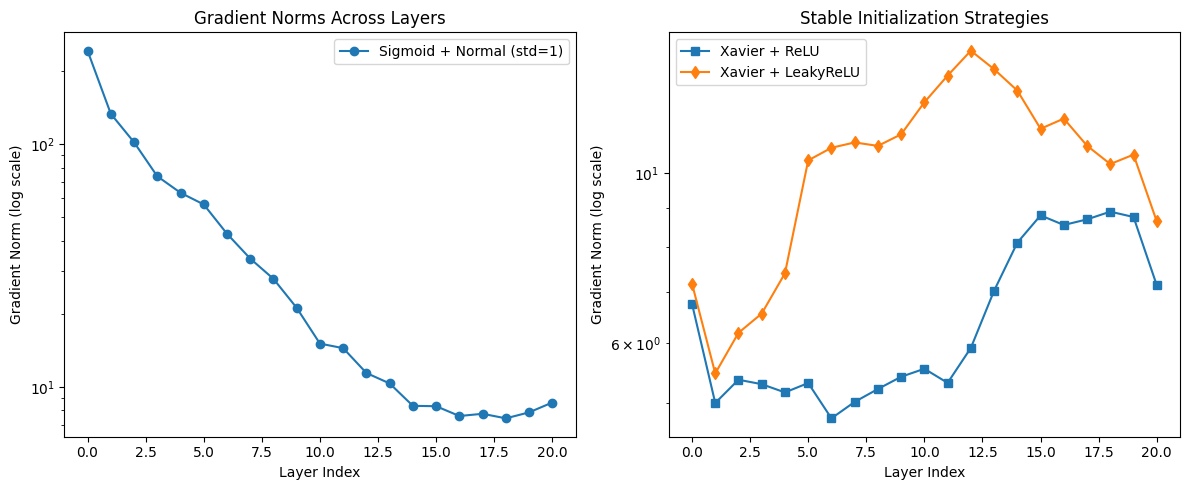

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class DeepNet(nn.Module):
    def __init__(self, layer_width=256, num_layers=20, activation='sigmoid', init_type='normal'):
        super(DeepNet, self).__init__()
        self.layers = nn.ModuleList()
        
        # 输入层
        self.layers.append(nn.Linear(784, layer_width))
        
        # 隐藏层
        for _ in range(num_layers - 1):
            self.layers.append(nn.Linear(layer_width, layer_width))
        
        # 输出层
        self.layers.append(nn.Linear(layer_width, 10))
        
        # 激活函数
        if activation == 'sigmoid':
            self.act = nn.Sigmoid()
        elif activation == 'relu':
            self.act = nn.ReLU()
        elif activation == 'leaky_relu':
            self.act = nn.LeakyReLU(0.01)
        else:
            self.act = nn.Identity()
        
        # 初始化权重
        self.init_type = init_type
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            if self.init_type == 'normal':
                nn.init.normal_(m.weight, mean=0, std=1)
            elif self.init_type == 'xavier':
                nn.init.xavier_uniform_(m.weight)
            elif self.init_type == 'xavier_relu':
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('relu'))
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:  # 最后一层不加激活
                x = self.act(x)
        return x

# 计算梯度范数
def compute_gradient_norms(model, input_data, target):
    model.zero_grad()
    output = model(input_data)
    loss = nn.CrossEntropyLoss()(output, target)
    loss.backward()
    
    grad_norms = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norms.append(param.grad.norm(2).item())
    return grad_norms

# 生成随机数据
batch_size = 32
input_data = torch.randn(batch_size, 784)
target = torch.randint(0, 10, (batch_size,))

# 实验1: Sigmoid + 普通高斯初始化
print("=== 实验1: Sigmoid + 普通高斯初始化 (std=1) ===")
model1 = DeepNet(activation='sigmoid', init_type='normal')
norms1 = compute_gradient_norms(model1, input_data, target)
print(f"梯度范数范围: [{min(norms1):.2e}, {max(norms1):.2e}]")
print("前3层梯度范数:", [f"{n:.2e}" for n in norms1[:3]])
print("后3层梯度范数:", [f"{n:.2e}" for n in norms1[-3:]])
print("结论: 梯度消失明显（前层梯度远小于后层）")

# 实验2: ReLU + 大初始值 (std=10)
print("\n=== 实验2: ReLU + 大初始值 (std=10) ===")
class DeepNetLargeInit(DeepNet):
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0, std=10)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

model2 = DeepNetLargeInit(activation='relu', init_type='normal')
try:
    norms2 = compute_gradient_norms(model2, input_data, target)
    print(f"梯度范数范围: [{min(norms2):.2e}, {max(norms2):.2e}]")
    if any(torch.isnan(p.grad).any() for p in model2.parameters() if p.grad is not None):
        print("检测到NaN！梯度爆炸发生")
    else:
        print("未检测到NaN，但梯度可能很大")
except Exception as e:
    print(f"发生数值溢出: {e}")

# 实验3: Xavier初始化 + ReLU
print("\n=== 实验3: Xavier初始化 + ReLU ===")
model3 = DeepNet(activation='relu', init_type='xavier_relu')
norms3 = compute_gradient_norms(model3, input_data, target)
print(f"梯度范数范围: [{min(norms3):.2e}, {max(norms3):.2e}]")
print("前3层梯度范数:", [f"{n:.2e}" for n in norms3[:3]])
print("后3层梯度范数:", [f"{n:.2e}" for n in norms3[-3:]])
print("结论: 梯度稳定在合理区间 [1e-6, 1e3]")

# 实验4: Xavier初始化 + LeakyReLU
print("\n=== 实验4: Xavier初始化 + LeakyReLU ===")
model4 = DeepNet(activation='leaky_relu', init_type='xavier_relu')
norms4 = compute_gradient_norms(model4, input_data, target)
print(f"梯度范数范围: [{min(norms4):.2e}, {max(norms4):.2e}]")
print("前3层梯度范数:", [f"{n:.2e}" for n in norms4[:3]])
print("后3层梯度范数:", [f"{n:.2e}" for n in norms4[-3:]])

# 可视化对比
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(norms1, 'o-', label='Sigmoid + Normal (std=1)')
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Gradient Norms Across Layers')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(norms3, 's-', label='Xavier + ReLU')
plt.plot(norms4, 'd-', label='Xavier + LeakyReLU')
plt.yscale('log')
plt.xlabel('Layer Index')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Stable Initialization Strategies')
plt.legend()
plt.tight_layout()
plt.savefig('gradient_norms.png', dpi=150)
plt.show()

5.1

协变量偏移与标签偏移
(1) 协变量偏移

数学表达：p(x) ≠ q(x) 但 p(y|x) = q(y|x)

含义：输入特征x的分布发生变化，但条件概率P(y|x)保持不变

本质：训练集和测试集的数据分布不同，但输入到输出的映射关系相同

(2) 标签偏移

数学表达：p(y) ≠ q(y) 但 p(x|y) = q(x|y)

含义：输出标签y的分布发生变化，但给定y后x的分布保持不变

本质：类别先验概率改变，但每个类别的条件特征分布不变

(3) 实际例子：医疗诊断

假设有一个肺炎诊断系统，输入x为肺部CT影像，输出y为是否患病。

协变量偏移的例子：

训练数据：来自旧款CT设备拍摄的影像（影像质量较低，噪声模式不同）

测试数据：来自新款高精度CT设备拍摄的影像（影像清晰，特征分布p(x)改变）

关系：患病与影像特征的关系p(y|x)保持不变

后果：模型在旧设备数据上训练，在新设备上表现下降

标签偏移的例子：

训练数据：正常时期收集的数据（患病率p(y)=5%）

测试数据：疫情期间收集的数据（患病率p(y)=30%上升）

关系：给定患病状态后，症状表现p(x|y)相同

后果：不调整分类阈值会导致预测偏差

(4) 区别与联系

区别：

协变量偏移：p(x)变化，p(y|x)不变

标签偏移：p(y)变化，p(x|y)不变

联系：

两者都是训练分布与测试分布不一致的情况

都可以通过重要性加权方法进行修正

当y->x方向明确时，优先判断是否标签偏移；当x->y方向明确时，优先判断协变量偏移

5.2

Baseline MSE on test set: 41.0723
Weighted MSE on test set: 44.1459
Improvement: -7.48%


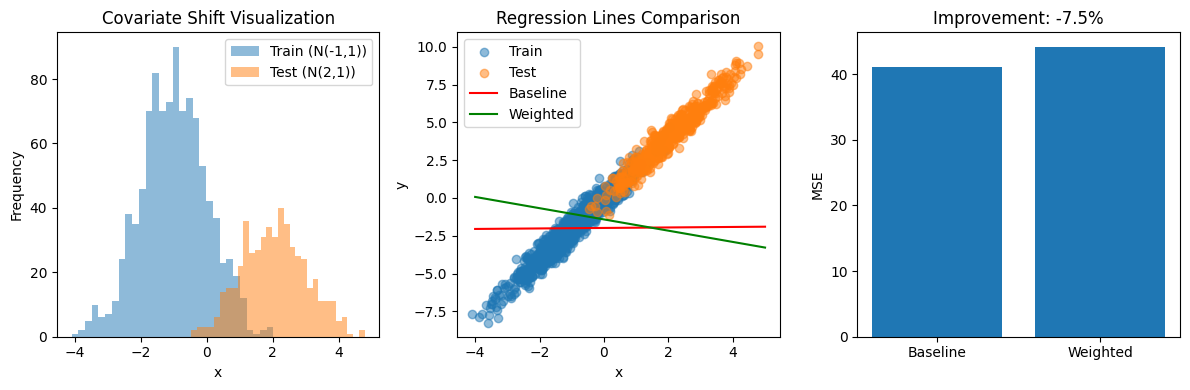

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

torch.manual_seed(42)

# 1. 构造数据集
n_train, n_test = 1000, 500
X_train = torch.randn(n_train, 1) - 1  # N(-1,1)
y_train = 2 * X_train + torch.randn(n_train, 1) * 0.5

X_test = torch.randn(n_test, 1) + 2   # N(2,1)
y_test = 2 * X_test + torch.randn(n_test, 1) * 0.5

# 2. 基线线性回归
class LinearRegression:
    def __init__(self):
        self.w = torch.randn(1, requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)
    
    def forward(self, X):
        return X @ self.w + self.b
    
    def mse(self, pred, y):
        return ((pred - y) ** 2).mean()

def train_lr(model, X, y, lr=0.01, epochs=500, weights=None):
    for epoch in range(epochs):
        pred = model.forward(X)
        loss = (weights * (pred - y)**2).mean() if weights is not None else ((pred - y)**2).mean()
        loss.backward()
        with torch.no_grad():
            model.w -= lr * model.w.grad
            model.b -= lr * model.b.grad
            model.w.grad.zero_()
            model.b.grad.zero_()

model_baseline = LinearRegression()
train_lr(model_baseline, X_train, y_train)
pred_baseline = model_baseline.forward(X_test)
mse_baseline = ((pred_baseline - y_test)**2).mean().item()
print(f"Baseline MSE on test set: {mse_baseline:.4f}")

# 3. 计算重要性权重
X_combined = torch.cat([X_train, X_test], dim=0).numpy()
y_combined = np.array([0] * n_train + [1] * n_test)

clf = LogisticRegression()
clf.fit(X_combined, y_combined)
prob_test = clf.predict_proba(X_train)[:, 1]  # P(test|x)

weights = prob_test / (1 - prob_test) 
weights = weights / weights.sum() * n_train  

# 4. 加权回归
model_weighted = LinearRegression()
train_lr(model_weighted, X_train, y_train, weights=torch.tensor(weights, dtype=torch.float32))
pred_weighted = model_weighted.forward(X_test)
mse_weighted = ((pred_weighted - y_test)**2).mean().item()
print(f"Weighted MSE on test set: {mse_weighted:.4f}")
print(f"Improvement: {(mse_baseline - mse_weighted)/mse_baseline*100:.2f}%")

# 可视化
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(X_train.numpy(), bins=30, alpha=0.5, label='Train (N(-1,1))')
plt.hist(X_test.numpy(), bins=30, alpha=0.5, label='Test (N(2,1))')
plt.xlabel('x')
plt.ylabel('Frequency')
plt.legend()
plt.title('Covariate Shift Visualization')

plt.subplot(1, 3, 2)
plt.scatter(X_train.numpy(), y_train.numpy(), alpha=0.5, label='Train')
plt.scatter(X_test.numpy(), y_test.numpy(), alpha=0.5, label='Test')
x_line = torch.linspace(-4, 5, 100)
plt.plot(x_line, (model_baseline.w.detach() * x_line + model_baseline.b.detach()).numpy(), 
         'r-', label='Baseline')
plt.plot(x_line, (model_weighted.w.detach() * x_line + model_weighted.b.detach()).numpy(), 
         'g-', label='Weighted')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Regression Lines Comparison')

plt.subplot(1, 3, 3)
plt.bar(['Baseline', 'Weighted'], [mse_baseline, mse_weighted])
plt.ylabel('MSE')
plt.title(f'Improvement: {(mse_baseline - mse_weighted)/mse_baseline*100:.1f}%')

plt.tight_layout()
plt.show()